In [1]:
# ==========================================
# 1. LOAD DATA & PREPARE FEATURES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Load data
DATA_PATH = Path(
    "../data/processed/feature_engineered_data.csv"
)

df = pd.read_csv(DATA_PATH)

df["Date"] = pd.to_datetime(df["Date"])

df = (
    df.sort_values(["Date", "Symbol"])
      .reset_index(drop=True)
)

target = "Target_Direction"

# Candidate features
features = [

    # Returns
    "Daily_Return",
    "Log_Return",
    "Intraday_Return",
    "High_Low_Range",

    # Lag Returns
    "Return_Lag_1",
    "Return_Lag_2",
    "Return_Lag_3",
    "Return_Lag_5",
    "Return_Lag_10",

    # Trend
    "Price_SMA_5_Ratio",
    "Price_SMA_10_Ratio",
    "Price_SMA_20_Ratio",
    "Price_SMA_50_Ratio",
    "Price_SMA_100_Ratio",
    "Price_SMA_200_Ratio",

    # Momentum
    "Momentum_5",
    "Momentum_10",
    "Momentum_20",
    "RSI_14",

    # MACD
    "MACD",
    "MACD_Signal",
    "MACD_Histogram",

    # Bollinger
    "BB_Position",

    # Volatility
    "Volatility_5",
    "Volatility_10",
    "Volatility_20",
    "Volatility_30",

    # Volume
    "Volume_Change",
    "Relative_Volume",

    # Calendar
    "Month",
    "DayOfWeek",
    "Quarter"
]

model_df = df[
    ["Date", "Symbol"] + features + [target]
].copy()

# Remove rows unavailable due to rolling calculations
model_df = model_df.dropna(
    subset=features + [target]
).reset_index(drop=True)

# Training period only for feature selection
train_df = model_df[
    model_df["Date"] < "2018-01-01"
].copy()

X_train = train_df[features]
y_train = train_df[target].astype(int)

print("Total candidate features:", len(features))
print("Training observations:", len(train_df))
print("Training period:",
      train_df["Date"].min(),
      "→",
      train_df["Date"].max())

print("\nTarget distribution:")
print(y_train.value_counts(normalize=True))

Total candidate features: 32
Training observations: 185114
Training period: 2000-10-19 00:00:00 → 2017-12-29 00:00:00

Target distribution:
Target_Direction
1    0.505067
0    0.494933
Name: proportion, dtype: float64


In [2]:
# ==========================================
# TIME-BASED TRAIN / VALIDATION / TEST SPLIT
# ==========================================

train_df = model_df[
    model_df["Date"] < "2018-01-01"
].copy()

val_df = model_df[
    (model_df["Date"] >= "2018-01-01") &
    (model_df["Date"] < "2020-01-01")
].copy()

test_df = model_df[
    model_df["Date"] >= "2020-01-01"
].copy()


print("Train Shape:", train_df.shape)
print("Validation Shape:", val_df.shape)
print("Test Shape:", test_df.shape)

print("\nTrain Period:")
print(train_df["Date"].min(), "→", train_df["Date"].max())

print("\nValidation Period:")
print(val_df["Date"].min(), "→", val_df["Date"].max())

print("\nTest Period:")
print(test_df["Date"].min(), "→", test_df["Date"].max())

Train Shape: (185114, 35)
Validation Shape: (24059, 35)
Test Shape: (16219, 35)

Train Period:
2000-10-19 00:00:00 → 2017-12-29 00:00:00

Validation Period:
2018-01-01 00:00:00 → 2019-12-31 00:00:00

Test Period:
2020-01-01 00:00:00 → 2021-04-29 00:00:00


In [3]:
# ==========================================
# 2. FEATURE CORRELATION ANALYSIS
# ==========================================

feature_corr = X_train.corr()

# Extract upper triangle
upper = feature_corr.where(
    np.triu(
        np.ones(feature_corr.shape),
        k=1
    ).astype(bool)
)

high_corr_pairs = (
    upper.stack()
         .reset_index()
)

high_corr_pairs.columns = [
    "Feature_1",
    "Feature_2",
    "Correlation"
]

high_corr_pairs["Abs_Correlation"] = (
    high_corr_pairs["Correlation"].abs()
)

high_corr_pairs = (
    high_corr_pairs[
        high_corr_pairs["Abs_Correlation"] >= 0.90
    ]
    .sort_values(
        "Abs_Correlation",
        ascending=False
    )
)

print(
    "Highly correlated feature pairs:",
    len(high_corr_pairs)
)

high_corr_pairs.head(30)

Highly correlated feature pairs: 3


,Feature_1,Feature_2,Correlation,Abs_Correlation
959,Month,Quarter,0.971529,0.971529
628,MACD,MACD_Signal,0.951939,0.951939
1,Daily_Return,Log_Return,0.936076,0.936076


In [4]:
# ==========================================
# 3. MUTUAL INFORMATION
# ==========================================

mi_scores = mutual_info_classif(
    X_train,
    y_train,
    random_state=42
)

mi_importance = pd.DataFrame({
    "Feature": features,
    "MI_Score": mi_scores
}).sort_values(
    "MI_Score",
    ascending=False
)

mi_importance

,Feature,MI_Score
31,Quarter,0.006468
30,DayOfWeek,0.006377
29,Month,0.002963
19,MACD,0.002348
12,Price_SMA_50_Ratio,0.001897
21,MACD_Histogram,0.001757
1,Log_Return,0.001596
0,Daily_Return,0.001592
15,Momentum_5,0.001485
8,Return_Lag_10,0.001446


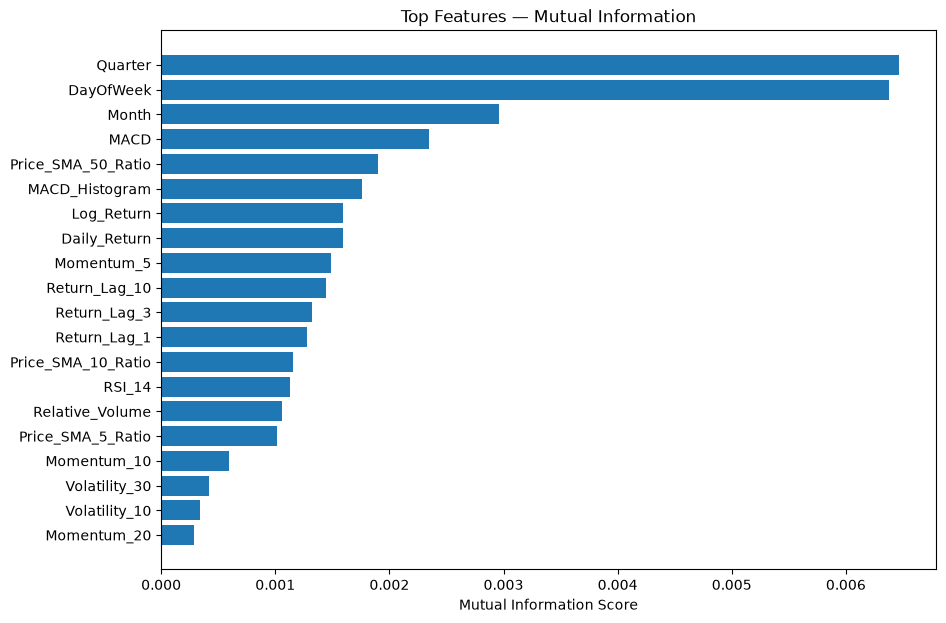

In [5]:
top_mi = mi_importance.head(20)

plt.figure(figsize=(10, 7))

plt.barh(
    top_mi["Feature"][::-1],
    top_mi["MI_Score"][::-1]
)

plt.xlabel("Mutual Information Score")
plt.title("Top Features — Mutual Information")

plt.show()

In [6]:
# ==========================================
# 4. TREE-BASED FEATURE IMPORTANCE
# ==========================================

# ---------- Random Forest ----------

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=10,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_importance = pd.DataFrame({
    "Feature": features,
    "RF_Importance": rf.feature_importances_
})


# ---------- XGBoost ----------

xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb.fit(
    X_train,
    y_train
)

xgb_importance = pd.DataFrame({
    "Feature": features,
    "XGB_Importance": xgb.feature_importances_
})


# ---------- Combine ----------

importance_df = (
    mi_importance
    .merge(
        rf_importance,
        on="Feature"
    )
    .merge(
        xgb_importance,
        on="Feature"
    )
)

importance_df.head()

,Feature,MI_Score,RF_Importance,XGB_Importance
0,Quarter,0.006468,0.009058,0.048499
1,DayOfWeek,0.006377,0.024825,0.039916
2,Month,0.002963,0.021560,0.037175
3,MACD,0.002348,0.027461,0.028345
4,Price_SMA_50_Ratio,0.001897,0.031198,0.033219


In [7]:
# ==========================================
# 5. COMBINED FEATURE RANKING
# ==========================================

importance_df["MI_Rank"] = (
    importance_df["MI_Score"]
    .rank(
        ascending=False,
        method="average"
    )
)

importance_df["RF_Rank"] = (
    importance_df["RF_Importance"]
    .rank(
        ascending=False,
        method="average"
    )
)

importance_df["XGB_Rank"] = (
    importance_df["XGB_Importance"]
    .rank(
        ascending=False,
        method="average"
    )
)

importance_df["Average_Rank"] = (
    importance_df[
        [
            "MI_Rank",
            "RF_Rank",
            "XGB_Rank"
        ]
    ]
    .mean(axis=1)
)

final_ranking = (
    importance_df
    .sort_values("Average_Rank")
    .reset_index(drop=True)
)

final_ranking[
    [
        "Feature",
        "MI_Rank",
        "RF_Rank",
        "XGB_Rank",
        "Average_Rank"
    ]
].head(20)

,Feature,MI_Rank,RF_Rank,XGB_Rank,Average_Rank
0,Momentum_5,9.0,4.0,3.0,5.333333
1,Return_Lag_1,12.0,1.0,6.0,6.333333
2,Price_SMA_10_Ratio,13.0,3.0,4.0,6.666667
3,Daily_Return,8.0,9.0,7.0,8.000000
4,Log_Return,7.0,10.0,8.0,8.333333
5,Price_SMA_50_Ratio,5.0,16.0,10.0,10.333333
6,DayOfWeek,2.0,30.0,2.0,11.333333
7,Quarter,1.0,32.0,1.0,11.333333
8,Return_Lag_10,10.0,6.0,19.0,11.666667
9,Relative_Volume,15.0,7.0,14.0,12.000000


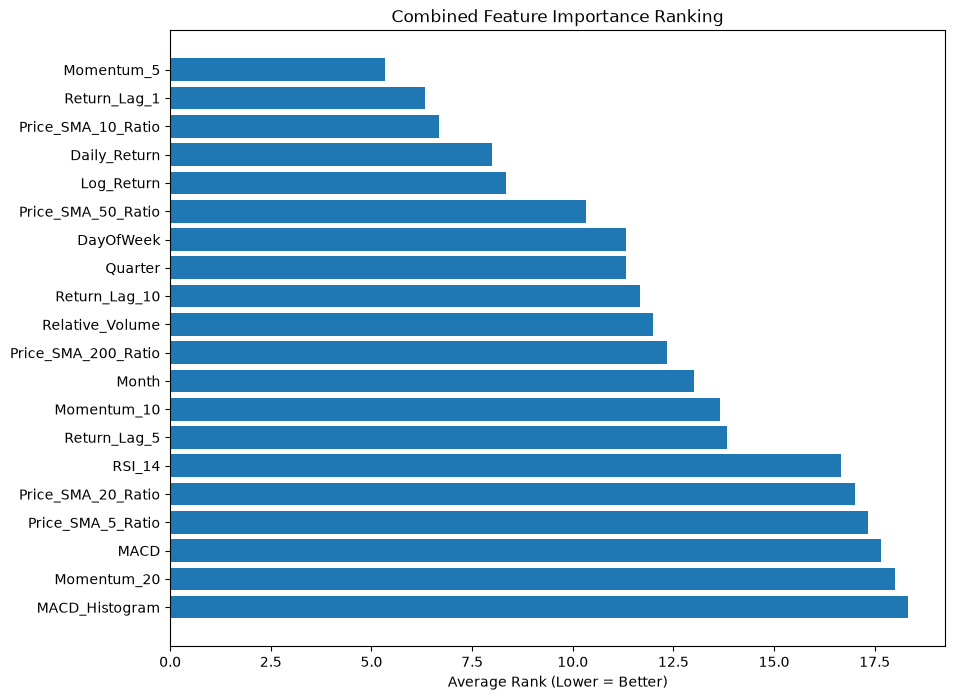

In [8]:
top_features = final_ranking.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Average_Rank"][::-1]
)

plt.xlabel("Average Rank (Lower = Better)")
plt.title("Combined Feature Importance Ranking")

plt.show()

In [9]:
high_corr_pairs.head(50)

,Feature_1,Feature_2,Correlation,Abs_Correlation
959,Month,Quarter,0.971529,0.971529
628,MACD,MACD_Signal,0.951939,0.951939
1,Daily_Return,Log_Return,0.936076,0.936076


In [10]:
top10_features = (
    final_ranking
    .head(10)["Feature"]
    .tolist()
)

top10_features

['Momentum_5',
 'Return_Lag_1',
 'Price_SMA_10_Ratio',
 'Daily_Return',
 'Log_Return',
 'Price_SMA_50_Ratio',
 'DayOfWeek',
 'Quarter',
 'Return_Lag_10',
 'Relative_Volume']

In [11]:
top15_features = (
    final_ranking
    .head(15)["Feature"]
    .tolist()
)

In [12]:
top20_features = (
    final_ranking
    .head(20)["Feature"]
    .tolist()
)

In [13]:
all_features = features.copy()

In [14]:
ranking_order = (
    final_ranking
    .set_index("Feature")["Average_Rank"]
    .to_dict()
)

selected_features = []

for feature in final_ranking["Feature"]:

    redundant = False

    for selected in selected_features:

        corr = abs(
            X_train[feature]
            .corr(X_train[selected])
        )

        if corr >= 0.90:
            redundant = True
            break

    if not redundant:
        selected_features.append(feature)

print("Original features:", len(features))
print("After correlation filtering:", len(selected_features))

selected_features

Original features: 32
After correlation filtering: 29


['Momentum_5',
 'Return_Lag_1',
 'Price_SMA_10_Ratio',
 'Daily_Return',
 'Price_SMA_50_Ratio',
 'DayOfWeek',
 'Quarter',
 'Return_Lag_10',
 'Relative_Volume',
 'Price_SMA_200_Ratio',
 'Momentum_10',
 'Return_Lag_5',
 'RSI_14',
 'Price_SMA_20_Ratio',
 'Price_SMA_5_Ratio',
 'MACD',
 'Momentum_20',
 'MACD_Histogram',
 'Return_Lag_3',
 'Volume_Change',
 'Return_Lag_2',
 'Price_SMA_100_Ratio',
 'BB_Position',
 'High_Low_Range',
 'Volatility_30',
 'Intraday_Return',
 'Volatility_10',
 'Volatility_5',
 'Volatility_20']

In [16]:
X_train = train_df[features]
y_train = train_df[target].astype(int)

X_val = val_df[features]
y_val = val_df[target].astype(int)

X_test = test_df[features]
y_test = test_df[target].astype(int)

print("\nX Shapes:")
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


X Shapes:
Train: (185114, 32)
Validation: (24059, 32)
Test: (16219, 32)


In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

feature_sets = {
    "Top 10": top10_features,
    "Top 15": top15_features,
    "Top 20": top20_features,
    "Correlation Filtered": selected_features,
    "All Features": all_features
}

results = []

for name, feature_set in feature_sets.items():

    X_train_fs = train_df[feature_set]
    X_val_fs = val_df[feature_set]

    model = XGBClassifier(
        n_estimators=400,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=10,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train_fs,
        y_train
    )

    pred = model.predict(X_val_fs)
    prob = model.predict_proba(X_val_fs)[:, 1]

    results.append({
        "Feature Set": name,
        "N_Features": len(feature_set),
        "Accuracy": accuracy_score(y_val, pred),
        "Precision": precision_score(y_val, pred),
        "Recall": recall_score(y_val, pred),
        "F1": f1_score(y_val, pred),
        "ROC_AUC": roc_auc_score(y_val, prob)
    })


feature_selection_results = (
    pd.DataFrame(results)
    .sort_values("ROC_AUC", ascending=False)
    .reset_index(drop=True)
)

feature_selection_results

,Feature Set,N_Features,Accuracy,Precision,Recall,F1,ROC_AUC
0,All Features,32,0.510287,0.506296,0.641443,0.565913,0.516913
1,Correlation Filtered,29,0.509705,0.505854,0.638771,0.564595,0.515044
2,Top 15,15,0.509539,0.505769,0.633342,0.562412,0.511610
3,Top 10,10,0.508251,0.504728,0.633008,0.561636,0.509366
4,Top 20,20,0.508292,0.504759,0.633342,0.561787,0.509332


In [18]:
calendar_features = [
    "Month",
    "DayOfWeek",
    "Quarter"
]

features_no_calendar = [
    f for f in features
    if f not in calendar_features
]

print("All features:", len(features))
print("Without calendar:", len(features_no_calendar))

All features: 32
Without calendar: 29


In [19]:
xgb_no_calendar = XGBClassifier(
    n_estimators=400,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_no_calendar.fit(
    train_df[features_no_calendar],
    y_train
)

pred = xgb_no_calendar.predict(
    val_df[features_no_calendar]
)

prob = xgb_no_calendar.predict_proba(
    val_df[features_no_calendar]
)[:, 1]

print("Accuracy:", accuracy_score(y_val, pred))
print("F1:", f1_score(y_val, pred))
print("ROC-AUC:", roc_auc_score(y_val, prob))

Accuracy: 0.5082921152167588
F1: 0.5698181818181818
ROC-AUC: 0.5124882141805105


In [20]:
# ==========================================
# RAW FEATURE ABLATION EXPERIMENT
# ==========================================

raw_features = [
    "Open",
    "Close",
    "Volume",
    "SMA_200",
    "EMA_12",
    "EMA_26"
]

features_with_raw = features + raw_features

print("Engineered Features:", len(features))
print("Engineered + Raw:", len(features_with_raw))

Engineered Features: 32
Engineered + Raw: 38


In [21]:
raw_model_df = df[
    ["Date", "Symbol"] +
    features_with_raw +
    [target]
].copy()

raw_model_df = (
    raw_model_df
    .dropna(subset=features_with_raw + [target])
    .reset_index(drop=True)
)

raw_train_df = raw_model_df[
    raw_model_df["Date"] < "2018-01-01"
].copy()

raw_val_df = raw_model_df[
    (raw_model_df["Date"] >= "2018-01-01") &
    (raw_model_df["Date"] < "2020-01-01")
].copy()

raw_test_df = raw_model_df[
    raw_model_df["Date"] >= "2020-01-01"
].copy()

print("Train:", raw_train_df.shape)
print("Validation:", raw_val_df.shape)
print("Test:", raw_test_df.shape)

Train: (185114, 41)
Validation: (24059, 41)
Test: (16219, 41)


In [22]:
print("Original Validation Rows:", len(val_df))
print("Raw Feature Validation Rows:", len(raw_val_df))

Original Validation Rows: 24059
Raw Feature Validation Rows: 24059


In [23]:
xgb_raw = XGBClassifier(
    n_estimators=400,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_raw.fit(
    raw_train_df[features_with_raw],
    raw_train_df[target].astype(int)
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [24]:
raw_val_pred = xgb_raw.predict(
    raw_val_df[features_with_raw]
)

raw_val_prob = xgb_raw.predict_proba(
    raw_val_df[features_with_raw]
)[:, 1]

raw_y_val = raw_val_df[target].astype(int)

In [25]:
print(
    "Accuracy:",
    accuracy_score(raw_y_val, raw_val_pred)
)

print(
    "Precision:",
    precision_score(raw_y_val, raw_val_pred)
)

print(
    "Recall:",
    recall_score(raw_y_val, raw_val_pred)
)

print(
    "F1:",
    f1_score(raw_y_val, raw_val_pred)
)

print(
    "ROC-AUC:",
    roc_auc_score(raw_y_val, raw_val_prob)
)

Accuracy: 0.5092065339374039
Precision: 0.505589809607697
Recall: 0.6232356134636265
F1: 0.558282208588957
ROC-AUC: 0.515727717332557


In [26]:
# ==========================================
# WALK-FORWARD VALIDATION
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

validation_years = [
    2015,
    2016,
    2017,
    2018,
    2019
]

walk_forward_results = []

for val_year in validation_years:

    # --------------------------------------
    # Expanding training window
    # --------------------------------------

    fold_train = model_df[
        model_df["Date"].dt.year < val_year
    ].copy()

    # Validation = one future year
    fold_val = model_df[
        model_df["Date"].dt.year == val_year
    ].copy()

    X_fold_train = fold_train[features]
    y_fold_train = fold_train[target].astype(int)

    X_fold_val = fold_val[features]
    y_fold_val = fold_val[target].astype(int)

    # --------------------------------------
    # Model
    # --------------------------------------

    model = XGBClassifier(
        n_estimators=400,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=10,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_fold_train,
        y_fold_train
    )

    # --------------------------------------
    # Prediction
    # --------------------------------------

    pred = model.predict(X_fold_val)

    prob = model.predict_proba(
        X_fold_val
    )[:, 1]

    # --------------------------------------
    # Metrics
    # --------------------------------------

    walk_forward_results.append({

        "Validation_Year": val_year,

        "Train_Start":
            fold_train["Date"].min().year,

        "Train_End":
            fold_train["Date"].max().year,

        "Train_Size":
            len(fold_train),

        "Validation_Size":
            len(fold_val),

        "Accuracy":
            accuracy_score(
                y_fold_val,
                pred
            ),

        "Precision":
            precision_score(
                y_fold_val,
                pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_fold_val,
                pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_fold_val,
                pred,
                zero_division=0
            ),

        "ROC_AUC":
            roc_auc_score(
                y_fold_val,
                prob
            )
    })


walk_forward_df = pd.DataFrame(
    walk_forward_results
)

walk_forward_df

,Validation_Year,Train_Start,Train_End,Train_Size,Validation_Size,Accuracy,Precision,Recall,F1,ROC_AUC
0,2015,2000,2014,148707,12152,0.505678,0.505312,0.648276,0.567935,0.511041
1,2016,2000,2015,160859,12103,0.517888,0.517541,0.682413,0.588650,0.520286
2,2017,2000,2016,172962,12152,0.494322,0.499694,0.664495,0.570430,0.496887
3,2018,2000,2017,185114,12054,0.518749,0.513670,0.650358,0.573988,0.523328
4,2019,2000,2018,197168,12005,0.499042,0.496731,0.636989,0.558184,0.507733


In [27]:
metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC"
]

walk_forward_summary = pd.DataFrame({
    "Mean": walk_forward_df[
        metric_columns
    ].mean(),

    "Std": walk_forward_df[
        metric_columns
    ].std(),

    "Min": walk_forward_df[
        metric_columns
    ].min(),

    "Max": walk_forward_df[
        metric_columns
    ].max()
})

walk_forward_summary

,Mean,Std,Min,Max
Accuracy,0.507136,0.010981,0.494322,0.518749
Precision,0.506589,0.008894,0.496731,0.517541
Recall,0.656506,0.017475,0.636989,0.682413
F1,0.571837,0.011078,0.558184,0.588650
ROC_AUC,0.511855,0.010541,0.496887,0.523328


In [28]:
walk_forward_results = []

for val_year in validation_years:

    fold_train = model_df[
        model_df["Date"].dt.year < val_year
    ].copy()

    fold_val = model_df[
        model_df["Date"].dt.year == val_year
    ].copy()

    X_fold_train = fold_train[features]
    y_fold_train = fold_train[target].astype(int)

    X_fold_val = fold_val[features]
    y_fold_val = fold_val[target].astype(int)

    # --------------------------------------
    # Majority baseline
    # --------------------------------------

    majority_class = (
        y_fold_train.mode()[0]
    )

    baseline_pred = np.full(
        len(y_fold_val),
        majority_class
    )

    baseline_accuracy = accuracy_score(
        y_fold_val,
        baseline_pred
    )

    # --------------------------------------
    # XGBoost
    # --------------------------------------

    model = XGBClassifier(
        n_estimators=400,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=10,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_fold_train,
        y_fold_train
    )

    pred = model.predict(
        X_fold_val
    )

    prob = model.predict_proba(
        X_fold_val
    )[:, 1]

    walk_forward_results.append({

        "Year": val_year,

        "Train_Size":
            len(fold_train),

        "Validation_Size":
            len(fold_val),

        "Baseline_Accuracy":
            baseline_accuracy,

        "Accuracy":
            accuracy_score(
                y_fold_val,
                pred
            ),

        "Accuracy_Improvement":
            accuracy_score(
                y_fold_val,
                pred
            ) - baseline_accuracy,

        "Precision":
            precision_score(
                y_fold_val,
                pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_fold_val,
                pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_fold_val,
                pred,
                zero_division=0
            ),

        "ROC_AUC":
            roc_auc_score(
                y_fold_val,
                prob
            )
    })


walk_forward_df = pd.DataFrame(
    walk_forward_results
)

walk_forward_df

,Year,Train_Size,Validation_Size,Baseline_Accuracy,Accuracy,Accuracy_Improvement,Precision,Recall,F1,ROC_AUC
0,2015,148707,12152,0.501152,0.505678,0.004526,0.505312,0.648276,0.567935,0.511041
1,2016,160859,12103,0.505495,0.517888,0.012394,0.517541,0.682413,0.588650,0.520286
2,2017,172962,12152,0.505267,0.494322,-0.010945,0.499694,0.664495,0.570430,0.496887
3,2018,185114,12054,0.498507,0.518749,0.020242,0.513670,0.650358,0.573988,0.523328
4,2019,197168,12005,0.496793,0.499042,0.002249,0.496731,0.636989,0.558184,0.507733


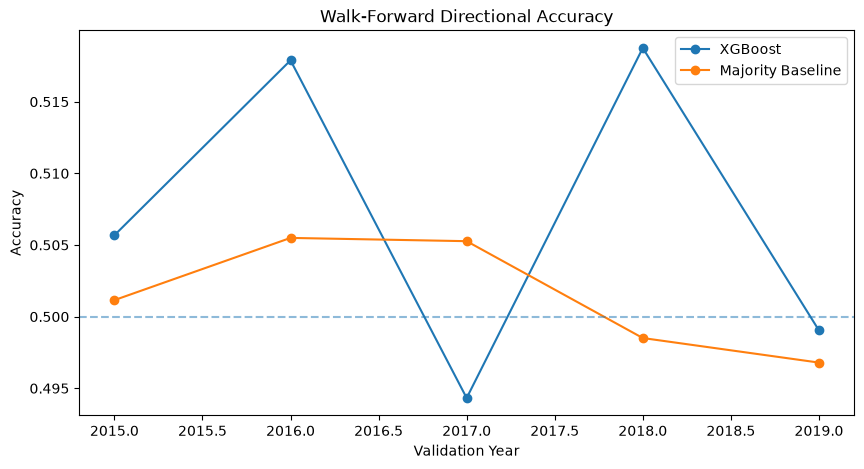

In [29]:
plt.figure(figsize=(10, 5))

plt.plot(
    walk_forward_df["Year"],
    walk_forward_df["Accuracy"],
    marker="o",
    label="XGBoost"
)

plt.plot(
    walk_forward_df["Year"],
    walk_forward_df["Baseline_Accuracy"],
    marker="o",
    label="Majority Baseline"
)

plt.axhline(
    0.5,
    linestyle="--",
    alpha=0.5
)

plt.xlabel("Validation Year")
plt.ylabel("Accuracy")

plt.title(
    "Walk-Forward Directional Accuracy"
)

plt.legend()

plt.show()

In [30]:
print(
    "Mean Accuracy:",
    walk_forward_df["Accuracy"].mean()
)

print(
    "Mean Baseline Accuracy:",
    walk_forward_df[
        "Baseline_Accuracy"
    ].mean()
)

print(
    "Mean Accuracy Improvement:",
    walk_forward_df[
        "Accuracy_Improvement"
    ].mean()
)

print(
    "Mean ROC-AUC:",
    walk_forward_df[
        "ROC_AUC"
    ].mean()
)

print(
    "ROC-AUC Std:",
    walk_forward_df[
        "ROC_AUC"
    ].std()
)

Mean Accuracy: 0.5071358311432863
Mean Baseline Accuracy: 0.5014425849363789
Mean Accuracy Improvement: 0.005693246206907354
Mean ROC-AUC: 0.5118547704811801
ROC-AUC Std: 0.01054060639164575


In [31]:
# ==========================================
# MULTI-HORIZON TARGET CREATION
# ==========================================

horizons = [1, 3, 5, 10]

for horizon in horizons:

    future_return = (
        df.groupby("Symbol")["Close"]
          .shift(-horizon)
        / df["Close"]
        - 1
    )

    df[f"Future_Return_{horizon}D"] = future_return

    df[f"Target_{horizon}D"] = np.where(
        future_return > 0,
        1,
        0
    )

    # Last `horizon` observations for each stock
    # don't have a valid future target.
    df.loc[
        future_return.isna(),
        f"Target_{horizon}D"
    ] = np.nan

In [32]:
horizon_results = []

for horizon in horizons:

    target_h = f"Target_{horizon}D"

    horizon_df = df[
        ["Date", "Symbol"] +
        features +
        [target_h]
    ].dropna(
        subset=features + [target_h]
    ).copy()

    for val_year in [2015, 2016, 2017, 2018, 2019]:

        fold_train = horizon_df[
            horizon_df["Date"].dt.year < val_year
        ]

        fold_val = horizon_df[
            horizon_df["Date"].dt.year == val_year
        ]

        X_train_h = fold_train[features]
        y_train_h = fold_train[target_h].astype(int)

        X_val_h = fold_val[features]
        y_val_h = fold_val[target_h].astype(int)

        # -------------------------------
        # Baseline
        # -------------------------------

        majority_class = y_train_h.mode()[0]

        baseline_pred = np.full(
            len(y_val_h),
            majority_class
        )

        baseline_acc = accuracy_score(
            y_val_h,
            baseline_pred
        )

        # -------------------------------
        # XGBoost
        # -------------------------------

        model = XGBClassifier(
            n_estimators=400,
            learning_rate=0.03,
            max_depth=4,
            min_child_weight=10,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        )

        model.fit(
            X_train_h,
            y_train_h
        )

        pred = model.predict(X_val_h)

        prob = model.predict_proba(
            X_val_h
        )[:, 1]

        accuracy = accuracy_score(
            y_val_h,
            pred
        )

        horizon_results.append({

            "Horizon": horizon,

            "Year": val_year,

            "Baseline_Accuracy":
                baseline_acc,

            "Accuracy":
                accuracy,

            "Improvement":
                accuracy - baseline_acc,

            "ROC_AUC":
                roc_auc_score(
                    y_val_h,
                    prob
                )
        })

In [33]:
horizon_results_df = pd.DataFrame(
    horizon_results
)

horizon_results_df

,Horizon,Year,Baseline_Accuracy,Accuracy,Improvement,ROC_AUC
0,1,2015,0.501152,0.505678,0.004526,0.511041
1,1,2016,0.505495,0.517888,0.012394,0.520286
2,1,2017,0.505267,0.494322,-0.010945,0.496887
3,1,2018,0.498507,0.518749,0.020242,0.523328
4,1,2019,0.496793,0.499042,0.002249,0.507733
5,3,2015,0.506254,0.504444,-0.001810,0.503598
6,3,2016,0.523920,0.531852,0.007932,0.521959
7,3,2017,0.544684,0.522301,-0.022383,0.503401
8,3,2018,0.504480,0.519413,0.014933,0.533130
9,3,2019,0.501958,0.500375,-0.001583,0.508344


In [34]:
horizon_summary = (
    horizon_results_df
    .groupby("Horizon")
    .agg(
        Mean_Baseline=(
            "Baseline_Accuracy",
            "mean"
        ),

        Mean_Accuracy=(
            "Accuracy",
            "mean"
        ),

        Mean_Improvement=(
            "Improvement",
            "mean"
        ),

        Mean_ROC_AUC=(
            "ROC_AUC",
            "mean"
        ),

        AUC_Std=(
            "ROC_AUC",
            "std"
        ),

        Min_AUC=(
            "ROC_AUC",
            "min"
        )
    )
    .reset_index()
)

horizon_summary

,Horizon,Mean_Baseline,Mean_Accuracy,Mean_Improvement,Mean_ROC_AUC,AUC_Std,Min_AUC
0,1,0.501443,0.507136,0.005693,0.511855,0.010541,0.496887
1,3,0.516259,0.515677,-0.000582,0.514087,0.013056,0.503401
2,5,0.522114,0.516184,-0.005931,0.510528,0.019599,0.479612
3,10,0.533430,0.519125,-0.014305,0.493930,0.027660,0.448734
